# Loading required libraries

In [48]:
library(ggplot2)
library(patchwork)
library(scales)
library(ggradar)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

## Figures and Files Setup

In [49]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

# Color palettes

In [59]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


cluster_palette <- c(

  "Tumor_bulk" = "#00B3A4",

  "Lymphoid_T" = "#D62828",

  "Myeloid_granulocytic" = "#6A00F4",

  "Tumor_myeloid" = "#80ED99",

  "Lymphoid_B" = "#FFB703",

  "Lymphatic_immune" = "#1F78B4",

  "Vascular/Endothelial" = "#00BFC4",

  "Stromal_fibroblasts" = "#B39DDB",

  "Stromal_NFC" = "#6C757D",

  "Epithelial_adjacent" = "#C9B29B",

  "Tumor_NFC" = "#CED4DA",

  "Lymphoid_enriched" = "#E76F51"
)

# Load the required data

In [51]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor_...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [52]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

In [53]:
#niches enrichment and pvalues
enr_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment.csv"))
pvalue_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"))

Rows: 19 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (12): Epithelial_adjacent, Lymphatic_immune, Lymphoid_B, Lymphoid_T, Lym...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 19 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (12): Epithelial_adjacent, Lymphatic_immune, Lymphoid_B, Lymphoid_T, Lym...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# B

In [54]:
cluster_composition <- niches_df %>%
    group_by(neighborhood, cell_category) %>%
    summarise(n_cells = n()) %>%
    ungroup() %>%
    group_by(neighborhood) %>%
    mutate("total_n" = sum(n_cells)) %>%
    ungroup() %>%
    mutate("percentage" = (n_cells / total_n) * 100) %>%
    select(!total_n)
cluster_composition

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by neighborhood and cell_category.
ℹ Output is grouped by neighborhood.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(neighborhood, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


neighborhood,cell_category,n_cells,percentage
<chr>,<chr>,<int>,<dbl>
Epithelial_adjacent,Actin+ cells,46,0.43220896
Epithelial_adjacent,B cells,10,0.09395847
Epithelial_adjacent,CD4+ T cells,56,0.52616743
Epithelial_adjacent,CD8+ T cells,178,1.67246077
Epithelial_adjacent,DCs,25,0.23489618
Epithelial_adjacent,Endothelial cells,88,0.82683454
Epithelial_adjacent,Epithelial cells,8163,76.69829935
Epithelial_adjacent,Granulocytes,334,3.13821291
Epithelial_adjacent,Lymphatic endothelial cells,148,1.39058536


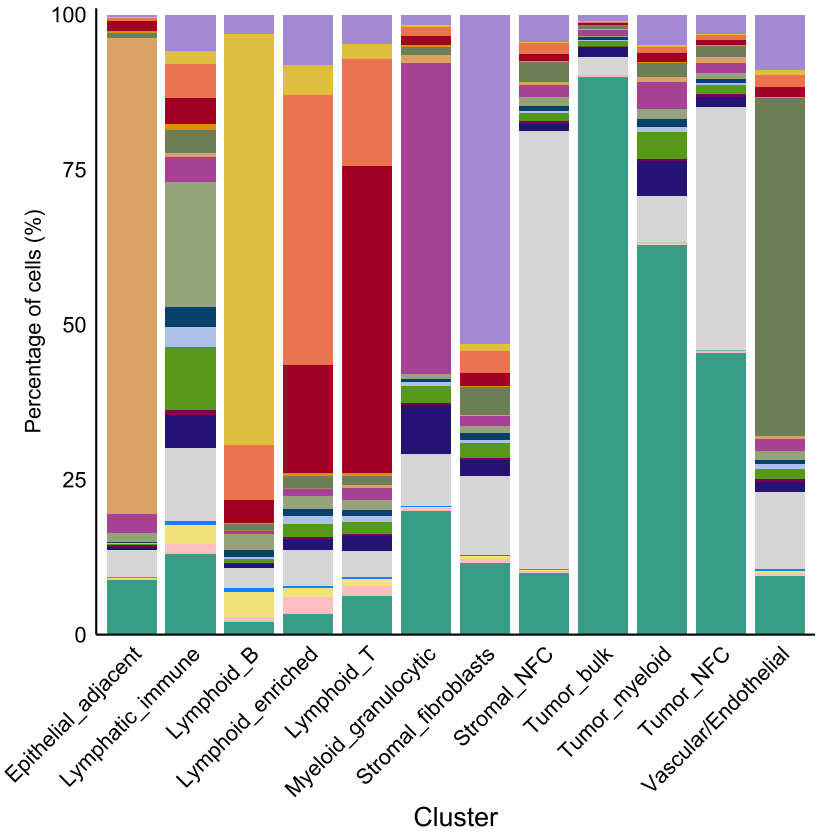

In [55]:
shared_margin <- margin(t = 5, r = 15, b = 5, l = 15)

p_cluster <- ggplot(
  cluster_composition,
  aes(x = neighborhood, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cluster",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),

    # restore y-axis text + title
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),

    # rotate x labels
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank(),
    plot.margin = shared_margin
  )

p_cluster

showtext_opts(dpi = 300)
ggsave(
  filename = file.path(results_dir, "cluster_composition_barplot.png"),
  plot = p_cluster,
  width = 7,
  height = 6,
  dpi = 300,
  bg = "white"
)

# C

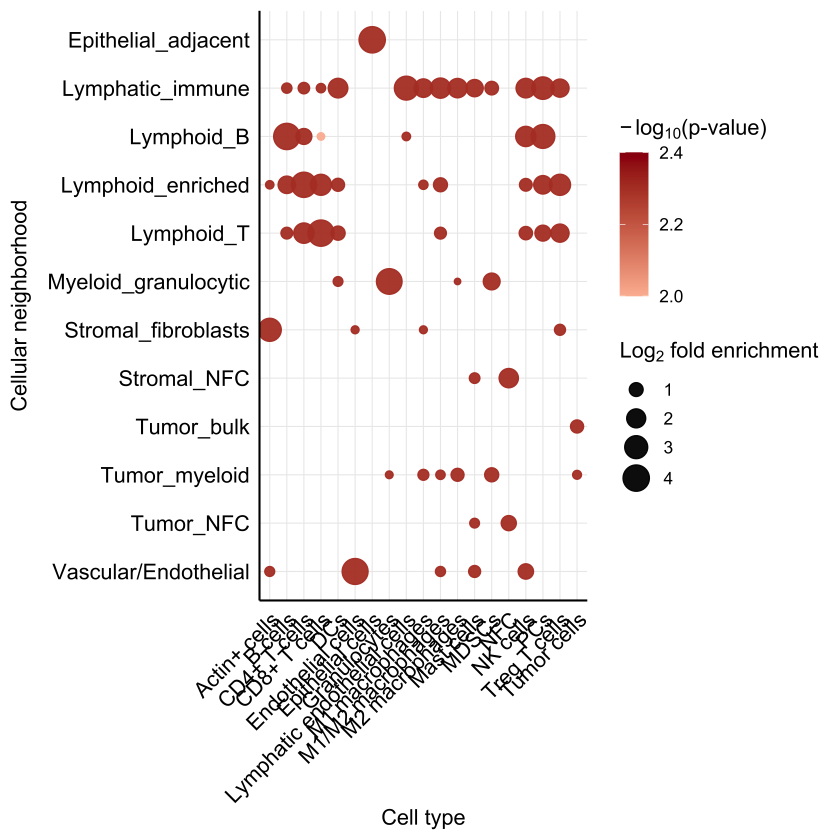

In [56]:
p_long <- pvalue_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "pvalue"
  )

enr_long <- enr_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "enrichment"
  )

df_plot <- enr_long %>%
  left_join(p_long, by = c("cell_category", "neighborhood")) %>%
  mutate(
    neighborhood = factor(neighborhood, levels = sort(unique(neighborhood))),
    cell_category = factor(cell_category)
  )

df_plot_filt <- df_plot %>%
  filter(enrichment > 0, pvalue < 0.01) %>%
  mutate(
    enrichment_cap = pmin(enrichment, 4),
    neglog10_p = -log10(pvalue)
  )

p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) + 
  scale_size_area(
    max_size = 7,
    breaks = c(1, 2, 3, 4),
    name = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
  low = "#fcbba1",
  high = "#99000d",
  name = expression(-log[10] * "(p-value)"),
  limits = c(2, 2.4),
  breaks = c(2.0, 2.2, 2.4)
) +
  labs(
    x = "Cell type",
    y = "Cellular neighborhood"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial", colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 13, colour = "black"),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line = element_line(color = "black")
  )
p
ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot = p,
  width = 10,
  height = 6,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

# D

In [57]:
#percentage of clusters per patient
patient_clusters <- niches_df %>%
  group_by(patient_ID, neighborhood) %>%
  summarise(n_cells = n()) %>%
  ungroup() %>%
  group_by(patient_ID) %>%
  mutate(percentage = (n_cells / sum(n_cells)) * 100) %>%
  ungroup() %>%
  mutate("patient_ID" = factor(patient_ID, levels = patient_ID_order)) %>%
  arrange(patient_ID)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and neighborhood.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, neighborhood))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


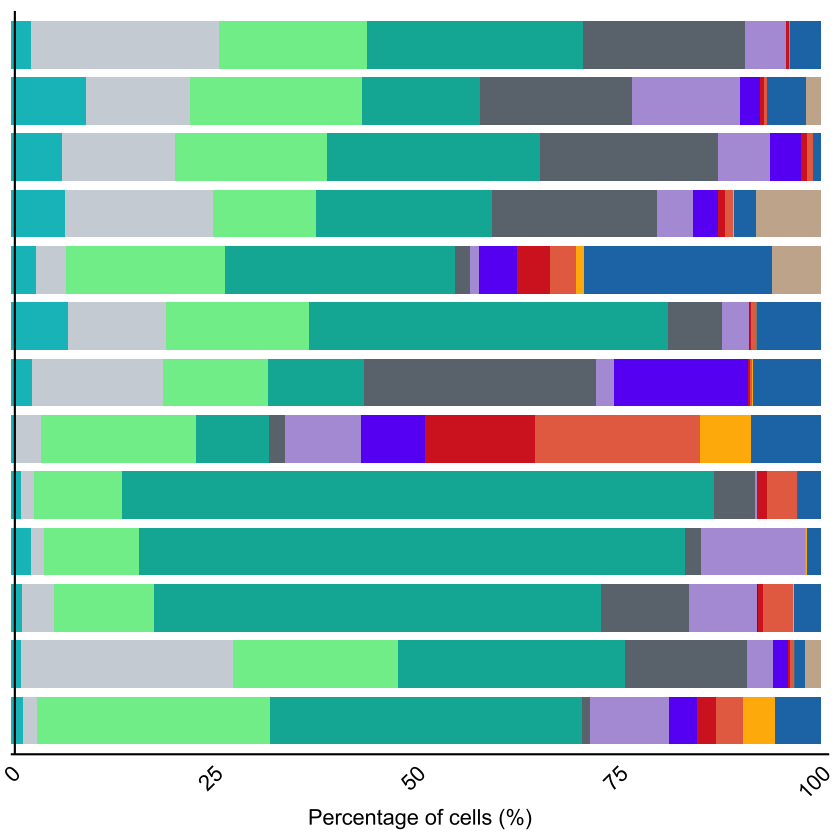

In [63]:
p_patient <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()
  )
p_patient

In [64]:
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "right",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend.pdf"),
  plot = p_patient_legend_only,
  width = 3,
  height = 4.5,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

#one on the bottom 
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend_bottom.pdf"),
  plot = p_patient_legend_only,
  width = 10,
  height = 1,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

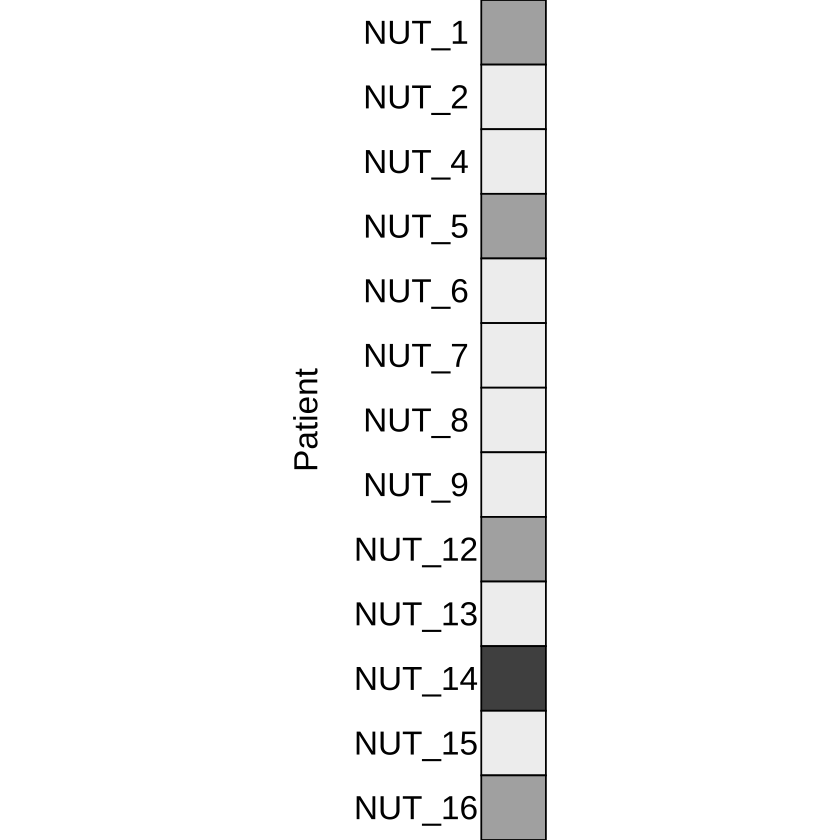

In [65]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

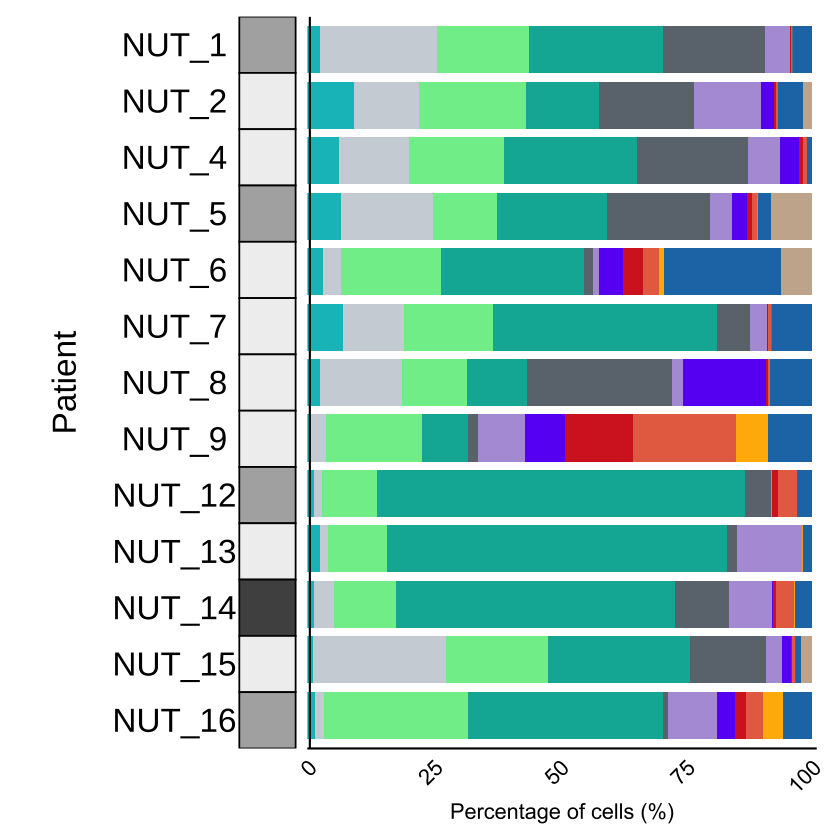

In [66]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_patient,
  ncol = 3,
  widths = c(1,-0.5,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = file.path(results_dir, "clusters_per_patient_tissue.pdf"),
  plot = final_plot,
  width = 8,
  height = 6,
  dpi = 300
)


# E

In [67]:
plot_niches <- function(df, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1, pt_size_fg = 1.5) {

  ggplot() +
    geom_point(
      data = df,
      aes(x = `Cell.Center.X`, y = `Cell.Center.Y`, color = neighborhood),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = cluster_palette,
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


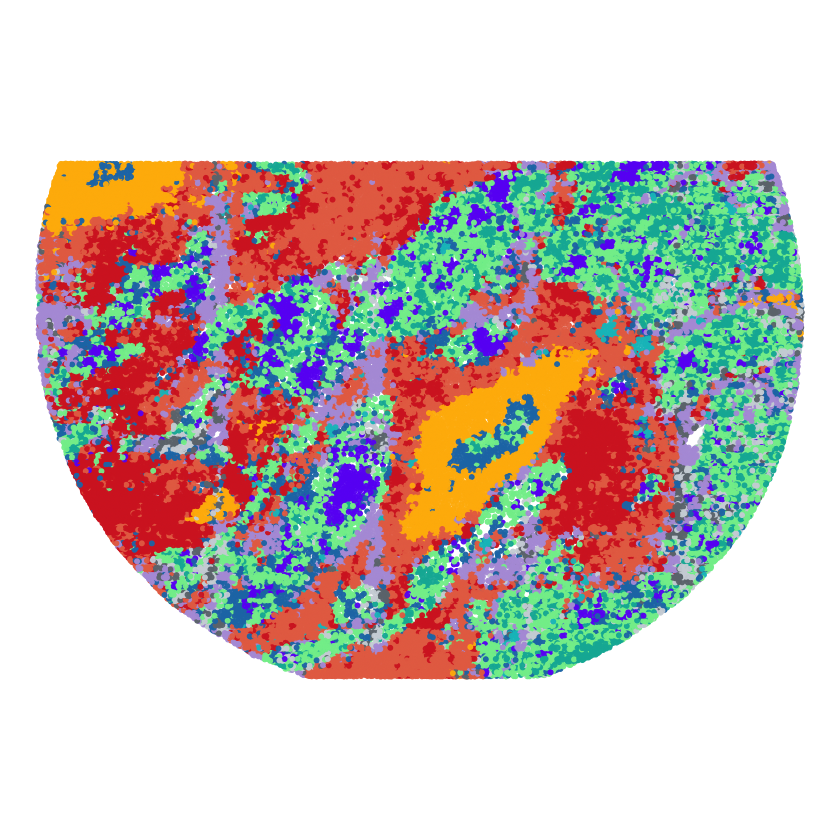

In [68]:
exp <- "NUT_9_ROI4"
df <- niches_df %>%
  filter(patient_exp == exp)

p <- plot_niches(
  df, pt_size_fg = 1)
  p


ggsave(filename = paste0(results_dir, "/NUT_9_ROI4_entire.png"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

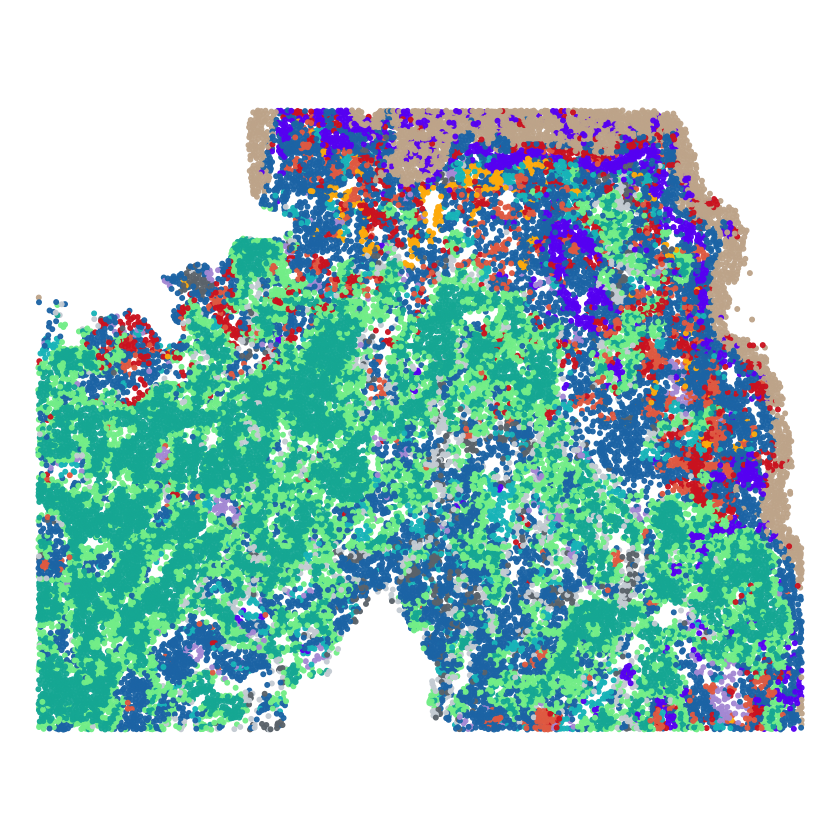

In [69]:
exp <- "NUT_6_ROI5"
df <- niches_df %>%
  filter(patient_exp == exp)

p <- plot_niches(
  df, pt_size_fg = 1)
  p


ggsave(filename = paste0(results_dir, "/NUT_6_ROI5_entire.png"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

In [72]:
niches_df %>% pull(patient_exp) %>% unique()

[1] "NUT_1_ROI1"   "NUT_1_ROI3"   "NUT_12_ROI5"  "NUT_13_ROI14" "NUT_13_ROI15"
 [6] "NUT_14_ROI8"  "NUT_14_ROI11" "NUT_15_ROI7"  "NUT_15_ROI16" "NUT_16_ROI17"
[11] "NUT_16_ROI19" "NUT_2_ROI1"   "NUT_4_ROI9"   "NUT_5_ROI11"  "NUT_5_ROI10" 
[16] "NUT_6_ROI5"   "NUT_7_ROI14"  "NUT_7_ROI13"  "NUT_8_ROI17"  "NUT_9_ROI4"  
[21] "NUT_9_ROI3"

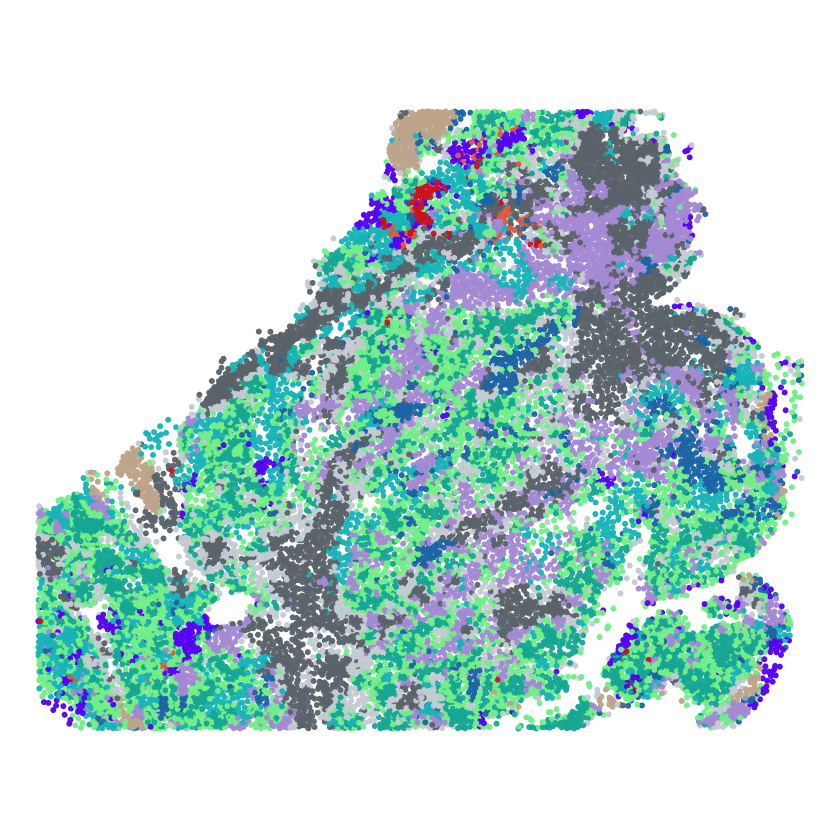

In [73]:
exp <- "NUT_2_ROI1"
df <- niches_df %>%
  filter(patient_exp == exp)

p <- plot_niches(
  df, pt_size_fg = 1)
  p


ggsave(filename = paste0(results_dir, "/NUT_2_ROI1_entire.png"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

# F

In [13]:
# let's get the content of the tumor myeloid niche per patient_exp then patient_ID
tumor_myeloid_content <- niches_df %>%
  filter(neighborhood == "Tumor_myeloid") %>%
  group_by(patient_exp, patient_ID, cell_category) %>%
  #percentage of every cell category
    summarise(n_cells = n()) %>%
    ungroup() %>%
    group_by(patient_exp, patient_ID) %>%
    mutate(percentage = (n_cells / sum(n_cells)) * 100) %>%
    ungroup() %>%
    select(!c(n_cells)) %>%
    group_by(patient_ID, cell_category) %>%
    summarise(percentage = mean(percentage)) %>%
    ungroup() %>%
    mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
    arrange(patient_ID) %>%
    filter(cell_category %in% c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "Granulocytes", "MDSCs")) 
tumor_myeloid_content

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,percentage
<fct>,<chr>,<dbl>
NUT_1,Granulocytes,0.06609385
NUT_1,M1 macrophages,1.64600095
NUT_1,M1/M2 macrophages,3.98240940
NUT_1,M2 macrophages,5.47866864
NUT_1,MDSCs,1.54486856
NUT_2,Granulocytes,4.39254339
NUT_2,M1 macrophages,0.64281123
NUT_2,M1/M2 macrophages,0.62138419
NUT_2,M2 macrophages,1.54274695


In [30]:
# Compute global min/max per cell type first
radar_scaled <- tumor_myeloid_content %>%
  group_by(cell_category) %>%
  mutate(percentage = rescale(percentage)) %>%  # scale using all patients
  ungroup()

plot_radar_patient <- function(patient, color) {
  radar_df <- radar_scaled %>%
    filter(patient_ID == patient) %>%
    pivot_wider(names_from = cell_category, values_from = percentage, values_fill = 0)
  
  ggradar(
    radar_df,
    group.colours            = color,
    values.radar             = c("0%", "50%", "100%"),
    grid.label.size          = 5,
    axis.label.size          = 5,
    group.line.width         = 1.2,
    group.point.size         = 3,
    background.circle.colour = "#F7F7F7",
    gridline.min.colour      = "grey70",
    gridline.mid.colour      = "grey70",
    gridline.max.colour      = "grey70",
    gridline.min.linetype    = "dashed",
    gridline.mid.linetype    = "dashed",
    gridline.max.linetype    = "dashed",
    fill                     = TRUE,
    fill.alpha               = 0.25,
    legend.position          = "none"
  ) +
    labs(title = patient) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16)
    )
}

p9 <- plot_radar_patient("NUT_9", "#B85AA6")
p6 <- plot_radar_patient("NUT_6", "#66A61E")

ggsave(
  filename = file.path(results_dir, "tumor_myeloid_radar_NUT_9.pdf"),
  plot = p9,
  width = 8,
  height = 10,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

ggsave(
  filename = file.path(results_dir, "tumor_myeloid_radar_NUT_6.pdf"),
  plot = p6,
  width = 8,
  height = 10,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

In [26]:
full_palette["M2 macrophages"]

M2 macrophages 
     "#66A61E"